# Define environment and agent

In [1]:
import gymnasium as gym
import collections
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#Hyperparameters
learning_rate = 0.0005
gamma         = 0.98
buffer_limit  = 50000
batch_size    = 32

class ReplayBuffer():
    def __init__(self):
        self.buffer = collections.deque(maxlen=buffer_limit)
    
    def put(self, transition):
        self.buffer.append(transition)
    
    def sample(self, n):
        mini_batch = random.sample(self.buffer, n)
        s_lst, a_lst, r_lst, s_prime_lst, done_mask_lst = [], [], [], [], []
        
        for transition in mini_batch:
            s, a, r, s_prime, done_mask = transition
            s_lst.append(s)
            a_lst.append([a])
            r_lst.append([r])
            s_prime_lst.append(s_prime)
            done_mask_lst.append([done_mask])

        return torch.tensor(s_lst, dtype=torch.float), torch.tensor(a_lst), \
               torch.tensor(r_lst), torch.tensor(s_prime_lst, dtype=torch.float), \
               torch.tensor(done_mask_lst)
    
    def size(self):
        return len(self.buffer)

class Qnet(nn.Module):
    def __init__(self):
        super(Qnet, self).__init__()
        self.fc1 = nn.Linear(4, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
      
    def sample_action(self, obs, epsilon):
        out = self.forward(obs)
        coin = random.random()
        if coin < epsilon:
            return random.randint(0,1)
        else : 
            return out.argmax().item()
            
def train(q, q_target, memory, optimizer):
    for i in range(10):
        s,a,r,s_prime,done_mask = memory.sample(batch_size)

        q_out = q(s)
        q_a = q_out.gather(1,a)
        max_q_prime = q_target(s_prime).max(1)[0].unsqueeze(1)
        target = r + gamma * max_q_prime * done_mask
        loss = F.smooth_l1_loss(q_a, target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# Train

In [ ]:
env = gym.make('CartPole-v1')
memory = ReplayBuffer()
q = Qnet()
q_target = Qnet()
q.load_state_dict(torch.load("./q.pt"))
q_target.load_state_dict(torch.load("./q_target.pt"))
# q_target.load_state_dict(q.state_dict())

print_interval = 20
score = 0.0  
optimizer = optim.Adam(q.parameters(), lr=learning_rate)

for n_epi in range(10000):
    epsilon = max(0.01, 0.08 - 0.01*(n_epi/200)) #Linear annealing from 8% to 1%
    s, _ = env.reset()
    done = False

    while not done:
        a = q.sample_action(torch.from_numpy(s).float(), epsilon)      
        s_prime, r, done, truncated, info = env.step(a)
        done_mask = 0.0 if done else 1.0
        memory.put((s,a,r/100.0,s_prime, done_mask))
        s = s_prime

        score += r
        if done:
            break
        
    if memory.size()>2000:
        train(q, q_target, memory, optimizer)

    if n_epi%print_interval==0 and n_epi!=0:
        q_target.load_state_dict(q.state_dict())
        print("n_episode :{}, score : {:.1f}, n_buffer : {}, eps : {:.1f}%".format(
                                n_epi, score/print_interval, memory.size(), epsilon*100))
        score = 0.0
env.close()


# Evaluate single episode

In [36]:
import gymnasium as gym
import torch
from gymnasium.wrappers import RecordVideo

# 1. 환경 생성 + 비디오 래퍼
env = gym.make("CartPole-v1", render_mode="rgb_array")
env = RecordVideo(
    env,
    video_folder="./videos_single",
    episode_trigger=lambda episode_id: True,  # 첫 에피소드 녹화
    name_prefix="cartpole_dqn"
)

# 2. 모델 로드
q = Qnet()
q.load_state_dict(torch.load("./q.pt", map_location="cpu"))
q.eval()

# 3. 에피소드 1개만 실행
s, _ = env.reset()
done = False
total_reward = 0.0
t = 0

while not done:
    with torch.no_grad():
        obs = torch.from_numpy(s).float().unsqueeze(0)  # (1,4)
        q_out = q(obs)                                  # (1,2)
        a = q_out.argmax(dim=1).item()                  # greedy action

    print(f"[t {t}] s={s} Q={q_out.squeeze(0).tolist()} a={a}")

    s, r, done, truncated, info = env.step(a)
    done = done or truncated
    total_reward += r
    t += 1

print(f"Episode finished. total_reward = {total_reward}")

env.close()


c:\Users\BioAI\anaconda3\envs\rl\lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at e:\Dropbox\rl_project\videos_single folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


[t 0] s=[ 0.03145729  0.0423349   0.01093754 -0.00475173] Q=[0.5643098950386047, 0.556877613067627] a=0
[t 1] s=[ 0.03230399 -0.1529422   0.0108425   0.29136196] Q=[0.5665678381919861, 0.5616923570632935] a=0
[t 2] s=[ 0.02924515 -0.34821704  0.01666974  0.58744466] Q=[0.5690152049064636, 0.5672315359115601] a=0
[t 3] s=[ 0.0222808  -0.54356843  0.02841864  0.8853317 ] Q=[0.5684961080551147, 0.5719815492630005] a=1
[t 4] s=[ 0.01140944 -0.3488436   0.04612527  0.60171634] Q=[0.570315957069397, 0.5706989169120789] a=1
[t 5] s=[ 0.00443256 -0.15439619  0.0581596   0.32391146] Q=[0.5697671175003052, 0.5680969953536987] a=0
[t 6] s=[ 0.00134464 -0.350296    0.06463782  0.6343536 ] Q=[0.5695638656616211, 0.571752667427063] a=1
[t 7] s=[-0.00566128 -0.15613237  0.0773249   0.36270666] Q=[0.5707912445068359, 0.5706728100776672] a=0
[t 8] s=[-0.00878393 -0.3522633   0.08457904  0.67873484] Q=[0.5681784749031067, 0.5723130702972412] a=1
[t 9] s=[-0.01582919 -0.15841182  0.09815373  0.41383368] 

# Visualize few frames

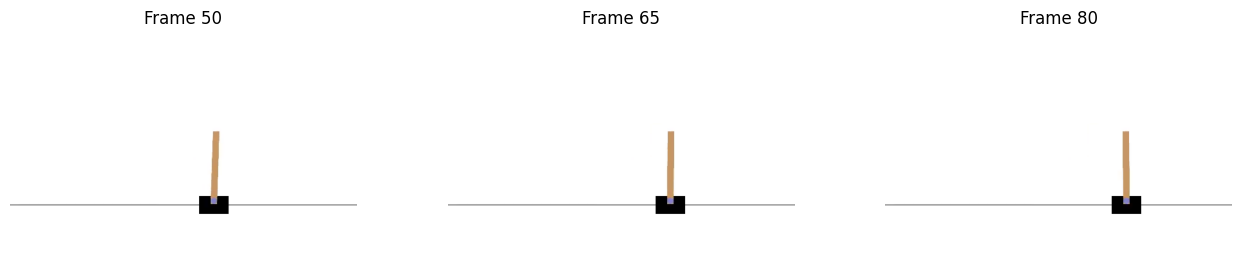

In [37]:
import cv2
import matplotlib.pyplot as plt

video_path = "./videos_single/cartpole_dqn-episode-0.mp4"
frame_idx = 50   # 보고 싶은 프레임 번호 (0부터 시작)
next_ = 15       # 몇 프레임 건너 볼 건지?
cap = cv2.VideoCapture(video_path)

cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ret, frame = cap.read()
cap.release()

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx+next_*1)
ret, frame_4 = cap.read()
cap.release()

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx+next_*2)
ret, frame_8 = cap.read()
cap.release()

frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
frame_4 = cv2.cvtColor(frame_4, cv2.COLOR_BGR2RGB)
frame_8 = cv2.cvtColor(frame_8, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16,3))
plt.subplot(131)
plt.imshow(frame)
plt.axis("off")
plt.title(f"Frame {frame_idx}")
plt.subplot(132)
plt.imshow(frame_4)
plt.axis("off")
plt.title(f"Frame {frame_idx+next_*1}")
plt.subplot(133)
plt.imshow(frame_8)
plt.axis("off")
plt.title(f"Frame {frame_idx+next_*2}")
plt.show()


 # Conver video to gif

In [ ]:
import imageio.v2 as imageio
for idx in range(5):
    mp4_path = f"./videos_DQN/dqn_cartpole-episode-{idx}.mp4"
    gif_path = f"./videos_DQN/dqn_cartpole-episode-{idx}.gif"

    reader = imageio.get_reader(mp4_path)
    fps = reader.get_meta_data()["fps"]

    frames = []
    for frame in reader:
        frames.append(frame)

    imageio.mimsave(gif_path, frames, fps=fps)
    print("GIF saved:", gif_path)

GIF saved: ./videos_DQN/dqn_cartpole-episode-0.gif
GIF saved: ./videos_DQN/dqn_cartpole-episode-1.gif
GIF saved: ./videos_DQN/dqn_cartpole-episode-2.gif
GIF saved: ./videos_DQN/dqn_cartpole-episode-3.gif
GIF saved: ./videos_DQN/dqn_cartpole-episode-4.gif


# TQDM으로 시각화하면서 학습시킴

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from tqdm.auto import tqdm

try:
    import gymnasium as gym
    from gymnasium.wrappers import RecordVideo
except ImportError:
    import gym
    # 구버전 gym은 RecordVideo 위치/동작이 다를 수 있음
    from gym.wrappers import RecordVideo

import torch
import torch.optim as optim

# ---------- 1) TRAIN ENV (no render, fastest) ----------
train_env = gym.make('CartPole-v1')

# ---------- 2) VIDEO ENV (only for recording) ----------
episode_to_save = [100, 500, 1000, 5000, 9999]

video_env = gym.make('CartPole-v1', render_mode="rgb_array")
video_env = RecordVideo(
    video_env,
    video_folder="./videos_DQN/",
    episode_trigger=lambda epi: True,
    name_prefix="dqn_cartpole"
)

# ---------- 3) Networks / Buffer ----------
q = Qnet()
q_target = Qnet()
q_target.load_state_dict(q.state_dict())

memory = ReplayBuffer()
optimizer = optim.Adam(q.parameters(), lr=learning_rate)

max_episodes   = 10000
print_interval = 20
buffer_warmup  = 2000

score = 0.0
started_training = False

epi_bar = tqdm(range(max_episodes), desc="Episodes", dynamic_ncols=True)

for n_epi in epi_bar:
    epsilon = max(0.01, 0.08 - 0.01*(n_epi/200))

    # ---------- Train episode ----------
    s, _ = train_env.reset()
    terminated = False
    truncated = False

    ep_return = 0.0

    while not (terminated or truncated):
        a = q.sample_action(torch.from_numpy(s).float(), epsilon)

        step_out = train_env.step(a)
        if len(step_out) == 5:
            s_prime, r, terminated, truncated, info = step_out
            done = terminated or truncated
        else:
            s_prime, r, done, info = step_out
            terminated, truncated = done, False

        done_mask = 0.0 if done else 1.0
        memory.put((s, a, r/100.0, s_prime, done_mask))

        s = s_prime
        ep_return += r

        if done:
            break

    score += ep_return

    # ---------- Warmup message (once) ----------
    if (not started_training) and (memory.size() >= buffer_warmup):
        print(f"[Episode {n_epi}] ReplayBuffer reached {memory.size()} >= {buffer_warmup}. Start training.")
        started_training = True

    # ---------- Train ----------
    if started_training:
        train(q, q_target, memory, optimizer)

    # ---------- Record video only on selected episodes ----------
    if n_epi in episode_to_save:
        s, _ = video_env.reset()  # RecordVideo가 내부 epi 카운트 증가
        terminated = False
        truncated = False

        while not (terminated or truncated):
            with torch.no_grad():
                a = q.sample_action(torch.from_numpy(s).float(), epsilon=0.0)  # greedy
            step_out = video_env.step(a)
            if len(step_out) == 5:
                s, r, terminated, truncated, info = step_out
            else:
                s, r, done, info = step_out
                terminated, truncated = done, False

    # ---------- Logging + target sync ----------
    if n_epi % print_interval == 0 and n_epi != 0:
        q_target.load_state_dict(q.state_dict())

        avg_score = score / print_interval
        epi_bar.set_postfix({
            "avg_score": f"{avg_score:.1f}",
            "buffer": memory.size(),
            "eps(%)": f"{epsilon*100:.1f}"
        })
        score = 0.0

train_env.close()
video_env.close()
torch.save(q.state_dict(), "./q.pt")
torch.save(q_target.state_dict(), "./q_target.pt")

Episodes:   0%|          | 0/10000 [00:00<?, ?it/s]

[Episode 118] ReplayBuffer reached 2001 >= 2000. Start training.
